# Import Modules and Functions

In [1]:
import sys, os

mod_dir = os.path.abspath('/Users/rangulo/projects/EtaCar_LEs/python')
sys.path.append(mod_dir)

from LC_utility import *

In [2]:
%load_ext autoreload
%autoreload 2

# Read in Data

In [3]:
## Original difference images
table_a57i = pd.read_csv('LC_tables/good2/LCref_a57_i.csv')
table_a57g = pd.read_csv('LC_tables/good2/LCref_a57_g.csv')
table_a57r = pd.read_csv('LC_tables/good2/LCref_a57_r.csv')
table_a57z = pd.read_csv('LC_tables/good2/LCref_a57_z.csv')

table_a54i = pd.read_csv('LC_tables/good2/LCref_a54_i.csv')
table_a54r = pd.read_csv('LC_tables/good2/LCref_a54_r.csv')
table_a54g = pd.read_csv('LC_tables/good2/LCref_a54_g.csv')
table_a54z = pd.read_csv('LC_tables/good2/LCref_a54_z.csv')

## segment 1
lc_df1i = readin_LCdf('LC_tables/good2/LCtable1_i.csv')
lc_df1g = readin_LCdf('LC_tables/good2/LCtable1_g.csv')
lc_df1r = readin_LCdf('LC_tables/good2/LCtable1_r.csv')
lc_df1z = readin_LCdf('LC_tables/good2/LCtable1_z.csv')


## segment 2
lc_df2i = readin_LCdf('LC_tables/good2/LCtable2_i.csv')
lc_df2g = readin_LCdf('LC_tables/good2/LCtable2_g.csv')
lc_df2r = readin_LCdf('LC_tables/good2/LCtable2_r.csv')
lc_df2z = readin_LCdf('LC_tables/good2/LCtable2_z.csv')

## segment 3
lc_df3i = readin_LCdf('LC_tables/good2/LCtable3_i.csv')
lc_df3g = readin_LCdf('LC_tables/good2/LCtable3_g.csv')
lc_df3r = readin_LCdf('LC_tables/good2/LCtable3_r.csv')
lc_df3z = readin_LCdf('LC_tables/good2/LCtable3_z.csv')

## segment 4
lc_df4i = readin_LCdf('LC_tables/good2/LCtable4_i.csv')
lc_df4g = readin_LCdf('LC_tables/good2/LCtable4_g.csv')
lc_df4r = readin_LCdf('LC_tables/good2/LCtable4_r.csv')
lc_df4z = readin_LCdf('LC_tables/good2/LCtable4_z.csv')

In [4]:
## Band subtracted diffs
btable_a54i = pd.read_csv('LC_tables/bandcorr/LCref_a54_i.csv')
btable_a54r = pd.read_csv('LC_tables/bandcorr/LCref_a54_r.csv')
btable_a54g = pd.read_csv('LC_tables/bandcorr/LCref_a54_g.csv')
btable_a54z = pd.read_csv('LC_tables/bandcorr/LCref_a54_z.csv')

## segment 2
blc_df2i = readin_LCdf('LC_tables/bandcorr/LCtable2_i.csv')
blc_df2g = readin_LCdf('LC_tables/bandcorr/LCtable2_g.csv')
blc_df2r = readin_LCdf('LC_tables/bandcorr/LCtable2_r.csv')
blc_df2z = readin_LCdf('LC_tables/bandcorr/LCtable2_z.csv')

## segment 3
blc_df3i = readin_LCdf('LC_tables/bandcorr/LCtable3_i.csv')
blc_df3g = readin_LCdf('LC_tables/bandcorr/LCtable3_g.csv')
blc_df3r = readin_LCdf('LC_tables/bandcorr/LCtable3_r.csv')
blc_df3z = readin_LCdf('LC_tables/bandcorr/LCtable3_z.csv')

## segment 4
blc_df4i = readin_LCdf('LC_tables/bandcorr/LCtable4_i.csv')
blc_df4g = readin_LCdf('LC_tables/bandcorr/LCtable4_g.csv')
blc_df4r = readin_LCdf('LC_tables/bandcorr/LCtable4_r.csv')
blc_df4z = readin_LCdf('LC_tables/bandcorr/LCtable4_z.csv')

In [5]:
### Some images need to be excluded due to quality
bad_expnums_a54g = pd.read_csv('txt_files/a54g_badims.csv')['a54'].values
bad_expnums_a54r = pd.read_csv('txt_files/a54r_badims.csv')['a54'].values
bad_expnums_a54i = pd.read_csv('txt_files/a54i_badims.csv')['a54'].values
bad_expnums_a54z = pd.read_csv('txt_files/a54z_badims.csv')['a54'].values

bad_expnums_a57g = pd.read_csv('txt_files/a57g_badims.csv')['a57'].values
bad_expnums_a57r = pd.read_csv('txt_files/a57r_badims.csv')['a57'].values
bad_expnums_a57i = pd.read_csv('txt_files/a57i_badims.csv')['a57'].values
bad_expnums_a57z = pd.read_csv('txt_files/a57z_badims.csv')['a57'].values


### Some images have bad bands -- we have versions with the bands subtracted (manually)
badb_expnums_a54g = pd.read_csv('txt_files/a54g_badbs.csv')['a54'].values
badb_expnums_a54r = pd.read_csv('txt_files/a54r_badbs.csv')['a54'].values
badb_expnums_a54i = pd.read_csv('txt_files/a54i_badbs.csv')['a54'].values
badb_expnums_a54z = pd.read_csv('txt_files/a54z_badbs.csv')['a54'].values

In [6]:
### Swap row entries of bad bands images
for i in badb_expnums_a54g:
    ind2 = lc_df2g.ix_equal('im_expnum',i)
    ind3 = lc_df3g.ix_equal('im_expnum',i)
    ind4 = lc_df4g.ix_equal('im_expnum',i)

    bind2 = blc_df2g.ix_equal('im_expnum',i)
    bind3 = blc_df3g.ix_equal('im_expnum',i)
    bind4 = blc_df4g.ix_equal('im_expnum',i)

    lc_df2g.t.loc[ind2,'muJyas2'] = blc_df2g.t.loc[bind2,'muJyas2']
    lc_df2g.t.loc[ind2,'muJyas2_err'] = blc_df2g.t.loc[bind2,'muJyas2_err']

    lc_df3g.t.loc[ind3,'muJyas2'] = blc_df3g.t.loc[bind3,'muJyas2']
    lc_df3g.t.loc[ind3,'muJyas2_err'] = blc_df3g.t.loc[bind3,'muJyas2_err']

    lc_df4g.t.loc[ind4,'muJyas2'] = blc_df4g.t.loc[bind4,'muJyas2']
    lc_df4g.t.loc[ind4,'muJyas2_err'] = blc_df4g.t.loc[bind4,'muJyas2_err']


for i in badb_expnums_a54r:
    ind2 = lc_df2r.ix_equal('im_expnum',i)
    ind3 = lc_df3r.ix_equal('im_expnum',i)
    ind4 = lc_df4r.ix_equal('im_expnum',i)

    bind2 = blc_df2r.ix_equal('im_expnum',i)
    bind3 = blc_df3r.ix_equal('im_expnum',i)
    bind4 = blc_df4r.ix_equal('im_expnum',i)

    lc_df2r.t.loc[ind2,'muJyas2'] = blc_df2r.t.loc[bind2,'muJyas2']
    lc_df2r.t.loc[ind2,'muJyas2_err'] = blc_df2r.t.loc[bind2,'muJyas2_err']

    lc_df3r.t.loc[ind3,'muJyas2'] = blc_df3r.t.loc[bind3,'muJyas2']
    lc_df3r.t.loc[ind3,'muJyas2_err'] = blc_df3r.t.loc[bind3,'muJyas2_err']

    lc_df4r.t.loc[ind4,'muJyas2'] = blc_df4r.t.loc[bind4,'muJyas2']
    lc_df4r.t.loc[ind4,'muJyas2_err'] = blc_df4r.t.loc[bind4,'muJyas2_err']


for i in badb_expnums_a54i:
    ind2 = lc_df2i.ix_equal('im_expnum',i)
    ind3 = lc_df3i.ix_equal('im_expnum',i)
    ind4 = lc_df4i.ix_equal('im_expnum',i)

    bind2 = blc_df2i.ix_equal('im_expnum',i)
    bind3 = blc_df3i.ix_equal('im_expnum',i)
    bind4 = blc_df4i.ix_equal('im_expnum',i)

    lc_df2i.t.loc[ind2,'muJyas2'] = blc_df2i.t.loc[bind2,'muJyas2']
    lc_df2i.t.loc[ind2,'muJyas2_err'] = blc_df2i.t.loc[bind2,'muJyas2_err']

    lc_df3i.t.loc[ind3,'muJyas2'] = blc_df3i.t.loc[bind3,'muJyas2']
    lc_df3i.t.loc[ind3,'muJyas2_err'] = blc_df3i.t.loc[bind3,'muJyas2_err']

    lc_df4i.t.loc[ind4,'muJyas2'] = blc_df4i.t.loc[bind4,'muJyas2']
    lc_df4i.t.loc[ind4,'muJyas2_err'] = blc_df4i.t.loc[bind4,'muJyas2_err']


for i in badb_expnums_a54z:
    ind2 = lc_df2z.ix_equal('im_expnum',i)
    ind3 = lc_df3z.ix_equal('im_expnum',i)
    ind4 = lc_df4z.ix_equal('im_expnum',i)
    
    bind2 = blc_df2z.ix_equal('im_expnum',i)
    bind3 = blc_df3z.ix_equal('im_expnum',i)
    bind4 = blc_df4z.ix_equal('im_expnum',i)
    
    lc_df2z.t.loc[ind2,'muJyas2'] = blc_df2z.t.loc[bind2,'muJyas2']
    lc_df2z.t.loc[ind2,'muJyas2_err'] = blc_df2z.t.loc[bind2,'muJyas2_err']
    
    lc_df3z.t.loc[ind3,'muJyas2'] = blc_df3z.t.loc[bind3,'muJyas2']
    lc_df3z.t.loc[ind3,'muJyas2_err'] = blc_df3z.t.loc[bind3,'muJyas2_err']
    
    lc_df4z.t.loc[ind4,'muJyas2'] = blc_df4z.t.loc[bind4,'muJyas2']
    lc_df4z.t.loc[ind4,'muJyas2_err'] = blc_df4z.t.loc[bind4,'muJyas2_err']

In [7]:
diffsa54 = pdastroclass()
diffsa54.load('txt_files/ec0915a54_diffs.txt')

diffsa57 = pdastroclass()
diffsa57.load('txt_files/ec0915a57_diffs.txt')

diffsa54.t['im_expnum'] = [int(re.search('\.(\d+)_ooi_',os.path.basename(diff_nm)).groups()[0]) for diff_nm in diffsa54.t['FITSNAME']]
diffsa57.t['im_expnum'] = [int(re.search('\.(\d+)_ooi_',os.path.basename(diff_nm)).groups()[0]) for diff_nm in diffsa57.t['FITSNAME']]

phot_a54_dict = {'g':3559443, 'r':3559444, 'i':3559445, 'z':3559446}
phot_a57_dict = {'g':3756051, 'r':3756052, 'i':3756053, 'z':3756054}

# Combine LCs

### Fitting Process for Each Segment

In [8]:
### Define uncertainty/error cut on flux error -- exclude outliers from fitting
### The working indices for fitting process -- run before the rest
### Also find peak location to fit light curves together
flag_inds(lc_df1g, f_lm=5.0, ferr_lm=1.0, bad_expnums=bad_expnums_a57g, bin_size='gauss', peak_range='full', diffstats=diffsa57)
flag_inds(lc_df1r, f_lm=15.0, ferr_lm=1.0, bad_expnums=bad_expnums_a57r, bin_size='gauss', peak_range='full', diffstats=diffsa57)
flag_inds(lc_df1i, f_lm=20.0, ferr_lm=1.0, bad_expnums=bad_expnums_a57i, bin_size='gauss', peak_range='full', diffstats=diffsa57)
flag_inds(lc_df1z, f_lm=15.0, ferr_lm=1.0, bad_expnums=bad_expnums_a57z, bin_size='gauss', peak_range='full', diffstats=diffsa57)

flag_inds(lc_df2g, f_lm=5.0, ferr_lm=1.0, bad_expnums=bad_expnums_a54g, bin_size='gauss', peak_range='full', diffstats=diffsa54)
flag_inds(lc_df2r, f_lm=10.0, ferr_lm=1.0, bad_expnums=bad_expnums_a54r, bin_size='gauss', peak_range='full', diffstats=diffsa54)
flag_inds(lc_df2i, f_lm=12.0, ferr_lm=1.0, bad_expnums=bad_expnums_a54i, bin_size='gauss', peak_range='full', diffstats=diffsa54)
flag_inds(lc_df2z, f_lm=12.0, ferr_lm=1.0, bad_expnums=bad_expnums_a54z, bin_size='gauss', peak_range='full', diffstats=diffsa54)

flag_inds(lc_df3g, f_lm=5.0, ferr_lm=1.0, bad_expnums=bad_expnums_a54g, bin_size='gauss', peak_range=[57300,58000], diffstats=diffsa54)
flag_inds(lc_df3r, f_lm=5.0, ferr_lm=1.0, bad_expnums=bad_expnums_a54r, bin_size='gauss', peak_range=[57300,58000], diffstats=diffsa54)
flag_inds(lc_df3i, f_lm=5.0, ferr_lm=1.0, bad_expnums=bad_expnums_a54i, bin_size='gauss', peak_range=[57300,58000], diffstats=diffsa54)
flag_inds(lc_df3z, f_lm=5.0, ferr_lm=1.0, bad_expnums=bad_expnums_a54z, bin_size='gauss', peak_range=[57300,58000], diffstats=diffsa54)

flag_inds(lc_df4g, f_lm=5.0, ferr_lm=1.0, bad_expnums=bad_expnums_a54g, bin_size='gauss', peak_range=None, diffstats=diffsa54)
flag_inds(lc_df4r, f_lm=5.0, ferr_lm=1.0, bad_expnums=bad_expnums_a54r, bin_size='gauss', peak_range=None, diffstats=diffsa54)
flag_inds(lc_df4i, f_lm=5.0, ferr_lm=1.0, bad_expnums=bad_expnums_a54i, bin_size='gauss', peak_range=None, diffstats=diffsa54)
flag_inds(lc_df4z, f_lm=5.0, ferr_lm=1.0, bad_expnums=bad_expnums_a54z, bin_size='gauss', peak_range=None, diffstats=diffsa54)

'Updated LC dataframe -- flagged working indices'

In [9]:
# ch_dfs = [lc_df2g, lc_df2r, lc_df2i, lc_df2z]

# for i in np.unique(ch_dfs[0].t['ID']):
#     print(i)
    # inds_sig_g = np.where(ch_dfs[0].t['ID'].eq(i) & ch_dfs[0].t['g_ixs_flag'].eq(True))[0]
    # inds_sig_r = np.where(ch_dfs[1].t['ID'].eq(i) & ch_dfs[1].t['g_ixs_flag'].eq(True))[0]
    # inds_sig_i = np.where(ch_dfs[2].t['ID'].eq(i) & ch_dfs[2].t['g_ixs_flag'].eq(True))[0]
    # inds_sig_z = np.where(ch_dfs[3].t['ID'].eq(i) & ch_dfs[3].t['g_ixs_flag'].eq(True))[0]

    # inds_sig_i = np.where(ch_dfs[2].t['ID'].eq(i) & ch_dfs[2].t['good_image'].eq(True) & (ch_dfs[2].t['muJyas2_err']<=1.0))[0]
    # inds_sig_i2 = np.where(ch_dfs[2].t['ID'].eq(i) & ch_dfs[2].t['g_ixs_flag'].eq(True))[0]
    # test_inds = np.where(ch_dfs[2].t['ID'].eq(i) & ch_dfs[2].t['good_image'].eq(True) & (ch_dfs[2].t['muJyas2_err']<=1.0) & (ch_dfs[2].t['mjd']>=58000))[0]
    # ch_dfs[2].calcaverage_sigmacutloop('muJyas2', indices=test_inds, noisecol='muJyas2_err', percentile_cut_firstiteration=70, Nsigma=5.0)
    # inds_sig_i2 = ch_dfs[2].statparams['ix_good']

    # plt.errorbar(ch_dfs[0].t.loc[inds_sig_g,'mjd'], ch_dfs[0].t.loc[inds_sig_g,'muJyas2'], yerr=ch_dfs[0].t.loc[inds_sig_g,'muJyas2_err'], fmt='o', ecolor='black', color='green')
    # plt.axvline(np.unique(ch_dfs[0].t.loc[inds_sig_g,'peak_loc']))
    
    # plt.errorbar(ch_dfs[1].t.loc[inds_sig_r,'mjd'], ch_dfs[1].t.loc[inds_sig_r,'muJyas2'], yerr=ch_dfs[1].t.loc[inds_sig_r,'muJyas2_err'], fmt='o', ecolor='black', color='red')
    # plt.axvline(np.unique(ch_dfs[1].t.loc[inds_sig_r,'peak_loc']))
    
    # plt.errorbar(ch_dfs[2].t.loc[inds_sig_i,'mjd'], ch_dfs[2].t.loc[inds_sig_i,'muJyas2'], yerr=ch_dfs[2].t.loc[inds_sig_i,'muJyas2_err'], fmt='o', ecolor='black', color='orange')
    # plt.errorbar(ch_dfs[2].t.loc[inds_sig_i2,'mjd'], ch_dfs[2].t.loc[inds_sig_i2,'muJyas2'], yerr=ch_dfs[2].t.loc[inds_sig_i2,'muJyas2_err'], fmt='o', ecolor='black', color='blue')
    # plt.axvline(np.unique(ch_dfs[2].t.loc[inds_sig_i,'peak_loc']))
    
    # plt.errorbar(ch_dfs[3].t.loc[inds_sig_z,'mjd'], ch_dfs[3].t.loc[inds_sig_z,'muJyas2'], yerr=ch_dfs[3].t.loc[inds_sig_z,'muJyas2_err'], fmt='o', ecolor='black', color='brown')
    # plt.axvline(np.unique(ch_dfs[3].t.loc[inds_sig_z,'peak_loc']))
    
    # plt.show()
    

In [10]:
### Fit LCs to a template
### 1st iteration --> template is an individual LC

## segment 1
templ_ID1 = 7
fit_parms1i = fit_LCs(lc_df1i, templ_ID=templ_ID1)

fit_parms1g = fit_LCs(lc_df1g, templ_ID=templ_ID1, tshift_ls=fit_parms1i[1])
fit_parms1r = fit_LCs(lc_df1r, templ_ID=templ_ID1, tshift_ls=fit_parms1i[1])
fit_parms1z = fit_LCs(lc_df1z, templ_ID=templ_ID1, tshift_ls=fit_parms1i[1])

## segment 2
templ_ID2 = 55
fit_parms2i = fit_LCs(lc_df2i, templ_ID=templ_ID2)
fit_parms2g = fit_LCs(lc_df2g, templ_ID=templ_ID2, tshift_ls=fit_parms2i[1])
fit_parms2r = fit_LCs(lc_df2r, templ_ID=templ_ID2, tshift_ls=fit_parms2i[1])
fit_parms2z = fit_LCs(lc_df2z, templ_ID=templ_ID2, tshift_ls=fit_parms2i[1])

## segment 3
    # specify range where there is a local maximimum (peak)
templ_ID3 = 93
fit_parms3i = fit_LCs(lc_df3i, templ_ID=templ_ID3)
fit_parms3g = fit_LCs(lc_df3g, templ_ID=templ_ID3, tshift_ls=fit_parms3i[1])
fit_parms3r = fit_LCs(lc_df3r, templ_ID=templ_ID3, tshift_ls=fit_parms3i[1])
fit_parms3z = fit_LCs(lc_df3z, templ_ID=templ_ID3, tshift_ls=fit_parms3i[1])

## segment 4
    # no tshift as the tail end seems aligned -- also no specific feature to pinpoint
templ_ID4 = 23
fit_parms4i = fit_LCs(lc_df4i, templ_ID=templ_ID4)
fit_parms4g = fit_LCs(lc_df4g, templ_ID=templ_ID4, tshift_ls=fit_parms4i[1])
fit_parms4r = fit_LCs(lc_df4r, templ_ID=templ_ID4, tshift_ls=fit_parms4i[1])
fit_parms4z = fit_LCs(lc_df4z, templ_ID=templ_ID4, tshift_ls=fit_parms4i[1])

In [11]:
### Create data frame of aligned and combined LCs

# ## segment 1
comb1g = get_combLCs(lc_df1g, fit_parms1g)
comb1r = get_combLCs(lc_df1r, fit_parms1r)
comb1i = get_combLCs(lc_df1i, fit_parms1i)
comb1z = get_combLCs(lc_df1z, fit_parms1z)

# ## segment 2
comb2g = get_combLCs(lc_df2g, fit_parms2g)
comb2r = get_combLCs(lc_df2r, fit_parms2r)
comb2i = get_combLCs(lc_df2i, fit_parms2i)
comb2z = get_combLCs(lc_df2z, fit_parms2z)

# ## segment 3
comb3g = get_combLCs(lc_df3g, fit_parms3g)
comb3r = get_combLCs(lc_df3r, fit_parms3r)
comb3i = get_combLCs(lc_df3i, fit_parms3i)
comb3z = get_combLCs(lc_df3z, fit_parms3z)

# ## segment 4
comb4g = get_combLCs(lc_df4g, fit_parms4g)
comb4r = get_combLCs(lc_df4r, fit_parms4r)
comb4i = get_combLCs(lc_df4i, fit_parms4i)
comb4z = get_combLCs(lc_df4z, fit_parms4z)

In [12]:
### Get LC curve fit

# ## segment 1
co_t1g, co_mu1g, co_std1g = get_LCfit(comb1g, metric=1e5)
co_t1r, co_mu1r, co_std1r = get_LCfit(comb1r, metric=1e5)
co_t1i, co_mu1i, co_std1i = get_LCfit(comb1i, metric=1e5)
co_t1z, co_mu1z, co_std1z = get_LCfit(comb1z, metric=1e5)

# ## segment 2
co_t2g, co_mu2g, co_std2g = get_LCfit(comb2g, metric=1e5)
co_t2r, co_mu2r, co_std2r = get_LCfit(comb2r, metric=1e5)
co_t2i, co_mu2i, co_std2i = get_LCfit(comb2i, metric=1e5)
co_t2z, co_mu2z, co_std2z = get_LCfit(comb2z, metric=1e5)

# ## segment 3
co_t3g, co_mu3g, co_std3g = get_LCfit(comb3g, metric=1e5)
co_t3r, co_mu3r, co_std3r = get_LCfit(comb3r, metric=1e5)
co_t3i, co_mu3i, co_std3i = get_LCfit(comb3i, metric=1e5)
co_t3z, co_mu3z, co_std3z = get_LCfit(comb3z, metric=1e5)

# ## segment 4
co_t4g, co_mu4g, co_std4g = get_LCfit(comb4g, metric=1e5)
co_t4r, co_mu4r, co_std4r = get_LCfit(comb4r, metric=1e5)
co_t4i, co_mu4i, co_std4i = get_LCfit(comb4i, metric=1e5)
co_t4z, co_mu4z, co_std4z = get_LCfit(comb4z, metric=1e5)

### See/Check Fitting Process

In [13]:
# test_range = np.arange(min(comb2g.t['mjd']), max(comb2g.t['mjd']),60)
# test_inds2 = []
# for i, val in enumerate(test_range):
#     if i == 0:
#         test_inds = comb2g.ix_inrange('mjd', lowlim=None, uplim=val)
#         comb2g.calcaverage_sigmacutloop('muJyas2', indices=test_inds, noisecol='muJyas2_err', percentile_cut_firstiteration=70, Nsigma=1.0)
#         test_inds2.append(comb2g.statparams['ix_good'])
#     elif i != 0 and i != len(test_range)-1 and i != len(test_range)-2:
#         test_inds = comb2g.ix_inrange('mjd', lowlim=val, uplim=test_range[i+1])
#         comb2g.calcaverage_sigmacutloop('muJyas2', indices=test_inds, noisecol='muJyas2_err', percentile_cut_firstiteration=70, Nsigma=1.0)
#         test_inds2.append(comb2g.statparams['ix_good'])
#     elif i == len(test_range)-2:
#         test_inds = comb2g.ix_inrange('mjd', lowlim=val, uplim=None)
#         comb2g.calcaverage_sigmacutloop('muJyas2', indices=test_inds, noisecol='muJyas2_err', percentile_cut_firstiteration=70, Nsigma=1.0)
#         test_inds2.append(comb2g.statparams['ix_good'])
# test_inds2 = np.concatenate(test_inds2)
# plt.scatter(comb2g.t['mjd'],comb2g.t['muJyas2'])
# plt.scatter(comb2g.t.loc[test_inds2,'mjd'],comb2g.t.loc[test_inds2,'muJyas2'])

In [14]:
### See individual LCs

## 4 segments (labelled 1-4)

# plot_lcs(lc_df2g, plot_orig=True)
# plot_lcs(lc_df1, plt_xl=60400)

In [15]:
### Check how peaks are found

# ch_df = lc_df2g
# lc_ids = np.unique(ch_df.t['ID'])
# for i in lc_ids: 
#     print(i)
#     # check_inds = np.where(ch_df.t['ID'].eq(i) & ch_df.t['g_ixs_flag'].eq(True))[0]
#     check_inds = np.where(ch_df.t['ID'].eq(i) & ~np.isnan(ch_df.t['muJyas2']))[0]
#     check_inds = check_inds[np.where((ch_df.t.loc[check_inds,'muJyas2']<5.0) & (ch_df.t.loc[check_inds,'muJyas2_err']<1.0))[0]]
#     plt.scatter(ch_df.t.loc[check_inds,'mjd'], ch_df.t.loc[check_inds,'muJyas2'], color='grey', alpha=0.5)
#     ch_t, ch_mu, ch_std = get_LCfit(ch_df,indices=check_inds, metric=5e4)

#     ch_model = interp1d(ch_t,ch_mu)
#     check_inds2 = np.where(abs(ch_model(ch_df.t.loc[check_inds,'mjd'].values)-ch_df.t.loc[check_inds,'muJyas2'].values) < 1.25)[0]
#     check_inds2 = check_inds[check_inds2]
    
#     plt.scatter(ch_df.t.loc[check_inds2,'mjd'], ch_df.t.loc[check_inds2,'muJyas2'])
#     plt.plot(ch_t,ch_mu, color='orange')
#     plt.ylim(-10, 5)

#     # # tpeak = find_t_peak(ch_t,ch_mu,ch_std, metric=None, t_range=[57300,58000])
#     # # print(tpeak)
#     # # plt.axvline(tpeak)
    
#     plt.show()

In [16]:
### See Fitting Process

# df = lc_df4g
# fit_ps = fit_parms4g
# t_ID = templ_ID4

# plot_LCfits(df,fit_ps, templ_ID=t_ID)

In [17]:
### See comb LCs

# df = lc_df4g
# fit_ps = fit_parms4g
# t_ID = templ_ID4

# for i in fit_ps[0]:
#     df_inds = np.where(df.t['ID'].eq(i) & df.t['g_ixs_flag'].eq(True))[0]
#     plt.errorbar(df.t.loc[df_inds,'new_mjd'], df.t.loc[df_inds,'new_muJyas2'], yerr=df.t.loc[df_inds,'new_muJyas2_err'], fmt='.', ecolor='black')

In [18]:
# ### See combined LC
# test_range = [0,-1]
# vals_g = [comb1g, co_t1g[test_range[0]:test_range[1]], co_mu1g[test_range[0]:test_range[1]], co_std1g[test_range[0]:test_range[1]]]
# vals_r = [comb1r, co_t1r[test_range[0]:test_range[1]], co_mu1r[test_range[0]:test_range[1]], co_std1r[test_range[0]:test_range[1]]]
# vals_i = [comb1i, co_t1i[test_range[0]:test_range[1]], co_mu1i[test_range[0]:test_range[1]], co_std1i[test_range[0]:test_range[1]]]
# vals_z = [comb1z, co_t1z[test_range[0]:test_range[1]], co_mu1z[test_range[0]:test_range[1]], co_std1z[test_range[0]:test_range[1]]]


# plt.errorbar(vals_g[0].t['mjd'], vals_g[0].t['muJyas2'], fmt='.', color='blue', alpha=0.25)
# plt.axhline(y=0, linestyle='--', color='black')
# plt.errorbar(vals_g[1], vals_g[2], fmt='--.', ecolor='black', color='orange') #,yerr=vals_g[3]
# plt.xlabel('MJD')
# plt.ylabel('$\mu$Jy/as$^2$')
# # plt.ylim(-1,3)
# plt.show()

# plt.errorbar(vals_r[0].t['mjd'], vals_r[0].t['muJyas2'], fmt='.', color='blue', alpha=0.25)
# plt.axhline(y=0, linestyle='--', color='black')
# plt.errorbar(vals_r[1], vals_r[2], fmt='--.', ecolor='black', color='orange') #,yerr=vals_r[3]
# plt.xlabel('MJD')
# plt.ylabel('$\mu$Jy/as$^2$')
# # plt.ylim(-1,3)
# plt.show()

# plt.errorbar(vals_i[0].t['mjd'], vals_i[0].t['muJyas2'], fmt='.', color='blue', alpha=0.25)
# plt.axhline(y=0, linestyle='--', color='black')
# plt.errorbar(vals_i[1], vals_i[2], fmt='--.', ecolor='black', color='orange') #,yerr=vals_i[3]
# plt.xlabel('MJD')
# plt.ylabel('$\mu$Jy/as$^2$')
# # plt.ylim(-1,3)
# plt.show()

# plt.errorbar(vals_z[0].t['mjd'], vals_z[0].t['muJyas2'], fmt='.', color='blue', alpha=0.25)
# plt.axhline(y=0, linestyle='--', color='black')
# plt.errorbar(vals_z[1], vals_z[2], fmt='--.', ecolor='black', color='orange') #,yerr=vals_z[3]
# plt.xlabel('MJD')
# plt.ylabel('$\mu$Jy/as$^2$')
# # plt.ylim(-1,3)
# plt.show()

# Model LC

### Combine Segments

In [19]:
c_t1g = co_t1g
c_mu1g = co_mu1g
c_std1g = co_std1g
c_t1r = co_t1r
c_mu1r = co_mu1r
c_std1r = co_std1r
c_t1i = co_t1i
c_mu1i = co_mu1i
c_std1i = co_std1i
c_t1z = co_t1z
c_mu1z = co_mu1z
c_std1z = co_std1z

c_t2g = co_t2g
c_mu2g = co_mu2g
c_std2g = co_std2g
c_t2r = co_t2r
c_mu2r = co_mu2r
c_std2r = co_std2r
c_t2i = co_t2i
c_mu2i = co_mu2i
c_std2i = co_std2i
c_t2z = co_t2z
c_mu2z = co_mu2z
c_std2z = co_std2z

c_t3g = co_t3g
c_mu3g = co_mu3g
c_std3g = co_std3g
c_t3r = co_t3r
c_mu3r = co_mu3r
c_std3r = co_std3r
c_t3i = co_t3i
c_mu3i = co_mu3i
c_std3i = co_std3i
c_t3z = co_t3z
c_mu3z = co_mu3z
c_std3z = co_std3z

c_t4g = co_t4g
c_mu4g = co_mu4g
c_std4g = co_std4g
c_t4r = co_t4r
c_mu4r = co_mu4r
c_std4r = co_std4r
c_t4i = co_t4i
c_mu4i = co_mu4i
c_std4i = co_std4i
c_t4z = co_t4z
c_mu4z = co_mu4z
c_std4z = co_std4z

# c_t1g = co_t1g[:-400]
# c_mu1g = co_mu1g[:-400]
# c_std1g = co_std1g[:-400]
# c_t1r = co_t1r[:-500]
# c_mu1r = co_mu1r[:-500]
# c_std1r = co_std1r[:-500]
# c_t1z = co_t1z[:-600]
# c_mu1z = co_mu1z[:-600]
# c_std1z = co_std1z[:-600]

# c_t2g = co_t2g[400:]
# c_mu2g = co_mu2g[400:]
# c_std2g = co_std2g[400:]
# c_t2r = co_t2r[500:]
# c_mu2r = co_mu2r[500:]
# c_std2r = co_std2r[500:]
# c_t2z = co_t2z[500:]
# c_mu2z = co_mu2z[500:]
# c_std2z = co_std2z[500:]

# c_t3g = co_t3g[:-150]
# c_mu3g = co_mu3g[:-150]
# c_std3g = co_std3g[:-150]
# c_t3r = co_t3r[:-150]
# c_mu3r = co_mu3r[:-150]
# c_std3r = co_std3r[:-150]
# c_t3i = co_t3i[:-150]
# c_mu3i = co_mu3i[:-150]
# c_std3i = co_std3i[:-150]
# c_t3z = co_t3z[:-150]
# c_mu3z = co_mu3z[:-150]
# c_std3z = co_std3z[:-150]

In [20]:
### Fit segments with overlap -- i band

tshiftm21i1 = find_t_shift(c_t2i, c_mu2i, c_std2i, c_t1i, c_mu1i, c_std1i)
tshiftm21i, am21i, bm21i = get_tshift_scale_offset(c_t2i, c_mu2i, c_std2i, c_t1i, c_mu1i, c_std1i, tshift_d=tshiftm21i1)

# define peaks to use in fitting (see LC)
t_pm2 = find_t_peak(c_t2i,c_mu2i,c_std2i, metric=None, t_range=[59000,60000])
t_pm3 = find_t_peak(c_t3i,c_mu3i,c_std3i, metric=None, t_range=[57000,57800])
tshiftm23i1 = t_pm3 - t_pm2
tshiftm23i, am23i, bm23i = get_tshift_scale_offset(c_t2i, c_mu2i, c_std2i, c_t3i, c_mu3i, c_std3i, tshift_d=tshiftm23i1)

# fit segment 4 to segment 3 after its been fitted to segment 2
m_t3i = c_t3i-tshiftm23i
m_f3i = am23i*c_mu3i+bm23i
m_ferr3i = am23i*c_std3i

tshiftm34i, am34i, bm34i = get_tshift_scale_offset(m_t3i, m_f3i, m_ferr3i, c_t4i, c_mu4i, c_std4i, tshift_d=-4450)



tshiftm21g, am21g, bm21g = get_tshift_scale_offset(c_t2g, c_mu2g, c_std2g, c_t1g, c_mu1g, c_std1g, tshift_d=tshiftm21i)
tshiftm23g, am23g, bm23g = get_tshift_scale_offset(c_t2g, c_mu2g, c_std2g, c_t3g, c_mu3g, c_std3g, tshift_d=tshiftm23i)
m_t3g = c_t3g-tshiftm23g
m_f3g = am23g*c_mu3g+bm23g
m_ferr3g = am23g*c_std3g
tshiftm34g, am34g, bm34g = get_tshift_scale_offset(m_t3g, m_f3g, m_ferr3g, c_t4g, c_mu4g, c_std4g, tshift_d=tshiftm34i)


tshiftm21r, am21r, bm21r = get_tshift_scale_offset(c_t2r, c_mu2r, c_std2r, c_t1r, c_mu1r, c_std1r, tshift_d=tshiftm21i)
tshiftm23r, am23r, bm23r = get_tshift_scale_offset(c_t2r, c_mu2r, c_std2r, c_t3r, c_mu3r, c_std3r, tshift_d=tshiftm23i)
m_t3r = c_t3r-tshiftm23r
m_f3r = am23r*c_mu3r+bm23r
m_ferr3r = am23r*c_std3r
tshiftm34r, am34r, bm34r = get_tshift_scale_offset(m_t3r, m_f3r, m_ferr3r, c_t4r, c_mu4r, c_std4r, tshift_d=tshiftm34i)


tshiftm21z, am21z, bm21z = get_tshift_scale_offset(c_t2z, c_mu2z, c_std2z, c_t1z, c_mu1z, c_std1z, tshift_d=tshiftm21i)
tshiftm23z, am23z, bm23z = get_tshift_scale_offset(c_t2z, c_mu2z, c_std2z, c_t3z, c_mu3z, c_std3z, tshift_d=tshiftm23i)
m_t3z = c_t3z-tshiftm23z
m_f3z = am23z*c_mu3z+bm23z
m_ferr3z = am23z*c_std3z
tshiftm34z, am34z, bm34z = get_tshift_scale_offset(m_t3z, m_f3z, m_ferr3z, c_t4z, c_mu4z, c_std4z, tshift_d=tshiftm34i)

In [21]:
### Combine Segments
    ## Combine model data
offsetmi = 50.5       # look at plot to decide

m_t1i = co_t1i-tshiftm21i
m_f1i = (am21i*co_mu1i+bm21i)+offsetmi
m_ferr1i = am21i*co_std1i

m_t2i = co_t2i
m_f2i = co_mu2i+offsetmi
m_ferr2i = co_std2i

m_t3i = co_t3i-tshiftm23i
m_f3i = (am23i*co_mu3i+bm23i)+offsetmi
m_ferr3i = am23i*co_std3i

m_t4i = co_t4i-tshiftm34i
m_f4i = (am34i*co_mu4i+bm34i)+offsetmi
m_ferr4i = am34i*co_std4i



offsetmg = 8.5
m_t1g = co_t1g-tshiftm21g
m_f1g = (am21g*co_mu1g+bm21g)+offsetmg
m_ferr1g = am21g*co_std1g
m_t2g = co_t2g
m_f2g = co_mu2g+offsetmg
m_ferr2g = co_std2g
m_t3g = co_t3g-tshiftm23g
m_f3g = (am23g*co_mu3g+bm23g)+offsetmg
m_ferr3g = am23g*co_std3g
m_t4g = co_t4g-tshiftm34g
m_f4g = (am34g*co_mu4g+bm34g)+offsetmg
m_ferr4g = am34g*co_std4g


offsetmr = 35.5
m_t1r = co_t1r-tshiftm21r
m_f1r = (am21r*co_mu1r+bm21r)+offsetmr
m_ferr1r = am21r*co_std1r
m_t2r = co_t2r
m_f2r = co_mu2r+offsetmr
m_ferr2r = co_std2r
m_t3r = co_t3r-tshiftm23r
m_f3r = (am23r*co_mu3r+bm23r)+offsetmr
m_ferr3r = am23r*co_std3r
m_t4r = co_t4r-tshiftm34r
m_f4r = (am34r*co_mu4r+bm34r)+offsetmr
m_ferr4r = am34r*co_std4r


offsetmz = 40.
m_t1z = co_t1z-tshiftm21z
m_f1z = (am21z*co_mu1z+bm21z)+offsetmz
m_ferr1z = am21z*co_std1z
m_t2z = co_t2z
m_f2z = co_mu2z+offsetmz
m_ferr2z = co_std2z
m_t3z = co_t3z-tshiftm23z
m_f3z = (am23z*co_mu3z+bm23z)+offsetmz
m_ferr3z = am23z*co_std3z
m_t4z = co_t4z-tshiftm34z
m_f4z = (am34z*co_mu4z+bm34z)+offsetmz
m_ferr4z = am34z*co_std4z

In [22]:
### Combine Segments - combine LC data
# 1
## g
fin_t1g = comb1g.t['mjd'].values-tshiftm21g
fin_f1g = (am21g*comb1g.t['muJyas2'].values+bm21g)+offsetmg
fin_ferr1g = am21g*comb1g.t['muJyas2_err'].values
## r
fin_t1r = comb1r.t['mjd'].values-tshiftm21r
fin_f1r = (am21r*comb1r.t['muJyas2'].values+bm21r)+offsetmr
fin_ferr1r = am21r*comb1r.t['muJyas2_err'].values
## i
fin_t1i = comb1i.t['mjd'].values-tshiftm21i
fin_f1i = (am21i*comb1i.t['muJyas2'].values+bm21i)+offsetmi
fin_ferr1i = am21i*comb1i.t['muJyas2_err'].values
## z
fin_t1z = comb1z.t['mjd'].values-tshiftm21z
fin_f1z = (am21z*comb1z.t['muJyas2'].values+bm21z)+offsetmz
fin_ferr1z = am21z*comb1z.t['muJyas2_err'].values

# 2
## g
fin_t2g = comb2g.t['mjd'].values
fin_f2g = comb2g.t['muJyas2'].values+offsetmg
fin_ferr2g = comb2g.t['muJyas2_err'].values
## r
fin_t2r = comb2r.t['mjd'].values
fin_f2r = comb2r.t['muJyas2'].values+offsetmr
fin_ferr2r = comb2r.t['muJyas2_err'].values
## i
fin_t2i = comb2i.t['mjd'].values
fin_f2i = comb2i.t['muJyas2'].values+offsetmi
fin_ferr2i = comb2i.t['muJyas2_err'].values
## z
fin_t2z = comb2z.t['mjd'].values
fin_f2z = comb2z.t['muJyas2'].values+offsetmz
fin_ferr2z = comb2z.t['muJyas2_err'].values

# 3
## g
fin_t3g = comb3g.t['mjd'].values-tshiftm23g
fin_f3g = (am23g*comb3g.t['muJyas2'].values+bm23g)+offsetmg
fin_ferr3g = am23g*comb3g.t['muJyas2_err'].values
## r
fin_t3r = comb3r.t['mjd'].values-tshiftm23r
fin_f3r = (am23r*comb3r.t['muJyas2'].values+bm23r)+offsetmr
fin_ferr3r = am23r*comb3r.t['muJyas2_err'].values
## i
fin_t3i = comb3i.t['mjd'].values-tshiftm23i
fin_f3i = (am23i*comb3i.t['muJyas2'].values+bm23i)+offsetmi
fin_ferr3i = am23i*comb3i.t['muJyas2_err'].values
## z
fin_t3z = comb3z.t['mjd'].values-tshiftm23z
fin_f3z = (am23z*comb3z.t['muJyas2'].values+bm23z)+offsetmz
fin_ferr3z = am23z*comb3z.t['muJyas2_err'].values

# 4
## g
fin_t4g = comb4g.t['mjd'].values-tshiftm34g
fin_f4g = (am34g*comb4g.t['muJyas2'].values+bm34g)+offsetmg
fin_ferr4g = am34g*comb4g.t['muJyas2_err'].values
## r
fin_t4r = comb4r.t['mjd'].values-tshiftm34r
fin_f4r = (am34r*comb4r.t['muJyas2'].values+bm34r)+offsetmr
fin_ferr4r = am34r*comb4r.t['muJyas2_err'].values
## i
fin_t4i = comb4i.t['mjd'].values-tshiftm34i
fin_f4i = (am34i*comb4i.t['muJyas2'].values+bm34i)+offsetmi
fin_ferr4i = am34i*comb4i.t['muJyas2_err'].values
## z
fin_t4z = comb4z.t['mjd'].values-tshiftm34z
fin_f4z = (am34z*comb4z.t['muJyas2'].values+bm34z)+offsetmz
fin_ferr4z = am34z*comb4z.t['muJyas2_err'].values

In [23]:
### Combine data into one table
## g
tls_mg = np.concatenate([fin_t1g, fin_t2g, fin_t3g, fin_t4g])
fls_mg = np.concatenate([fin_f1g, fin_f2g, fin_f3g, fin_f4g])
ferrls_mg = np.concatenate([fin_ferr1g, fin_ferr2g, fin_ferr3g, fin_ferr4g])
ord_inds_mg = tls_mg.argsort()
tls_mg = tls_mg[ord_inds_mg]
fls_mg = fls_mg[ord_inds_mg]
ferrls_mg = ferrls_mg[ord_inds_mg]
comb_m_datag = {'mjd': tls_mg, 'muJyas2': fls_mg, 'muJyas2_err': ferrls_mg}
comb_mg = pdastrostatsclass()
comb_mg.t = comb_mg.t.assign(**comb_m_datag)
## r
tls_mr = np.concatenate([fin_t1r, fin_t2r, fin_t3r, fin_t4r])
fls_mr = np.concatenate([fin_f1r, fin_f2r, fin_f3r, fin_f4r])
ferrls_mr = np.concatenate([fin_ferr1r, fin_ferr2r, fin_ferr3r, fin_ferr4r])
ord_inds_mr = tls_mr.argsort()
tls_mr = tls_mr[ord_inds_mr]
fls_mr = fls_mr[ord_inds_mr]
ferrls_mr = ferrls_mr[ord_inds_mr]
comb_m_datar = {'mjd': tls_mr, 'muJyas2': fls_mr, 'muJyas2_err': ferrls_mr}
comb_mr = pdastrostatsclass()
comb_mr.t = comb_mr.t.assign(**comb_m_datar)
## i
tls_mi = np.concatenate([fin_t1i, fin_t2i, fin_t3i, fin_t4i])
fls_mi = np.concatenate([fin_f1i, fin_f2i, fin_f3i, fin_f4i])
ferrls_mi = np.concatenate([fin_ferr1i, fin_ferr2i, fin_ferr3i, fin_ferr4i])
ord_inds_mi = tls_mi.argsort()
tls_mi = tls_mi[ord_inds_mi]
fls_mi = fls_mi[ord_inds_mi]
ferrls_mi = ferrls_mi[ord_inds_mi]
comb_m_datai = {'mjd': tls_mi, 'muJyas2': fls_mi, 'muJyas2_err': ferrls_mi}
comb_mi = pdastrostatsclass()
comb_mi.t = comb_mi.t.assign(**comb_m_datai)
## z
tls_mz = np.concatenate([fin_t1z, fin_t2z, fin_t3z, fin_t4z])
fls_mz = np.concatenate([fin_f1z, fin_f2z, fin_f3z, fin_f4z])
ferrls_mz = np.concatenate([fin_ferr1z, fin_ferr2z, fin_ferr3z, fin_ferr4z])
ord_inds_mz = tls_mz.argsort()
tls_mz = tls_mz[ord_inds_mz]
fls_mz = fls_mz[ord_inds_mz]
ferrls_mz = ferrls_mz[ord_inds_mz]
comb_m_dataz = {'mjd': tls_mz, 'muJyas2': fls_mz, 'muJyas2_err': ferrls_mz}
comb_mz = pdastrostatsclass()
comb_mz.t = comb_mz.t.assign(**comb_m_dataz)

In [24]:
### Create the model (LC_0)

m_tg, m_mug, m_stdg = get_LCfit(comb_mg, metric=1e5)

m_tr, m_mur, m_stdr = get_LCfit(comb_mr, metric=1e5)

m_ti, m_mui, m_stdi = get_LCfit(comb_mi, metric=1e5)

m_tz, m_muz, m_stdz = get_LCfit(comb_mz, metric=1e5)

In [25]:
### Save tables

comb_mg.t.to_csv('LC_tables/good2/models/gLC_data1.csv', index=False)
comb_mr.t.to_csv('LC_tables/good2/models/rLC_data1.csv', index=False)
comb_mi.t.to_csv('LC_tables/good2/models/iLC_data1.csv', index=False)
comb_mz.t.to_csv('LC_tables/good2/models/zLC_data1.csv', index=False)

lc_modelg = {'mjd':m_tg, 'muJyas2':m_mug, 'muJyas2_err':m_stdg}
lc_model_dg = pd.DataFrame(lc_modelg)
lc_model_dg.to_csv('LC_tables/good2/models/gLC_m1.csv', index=False)

lc_modelr = {'mjd':m_tr, 'muJyas2':m_mur, 'muJyas2_err':m_stdr}
lc_model_dr = pd.DataFrame(lc_modelr)
lc_model_dr.to_csv('LC_tables/good2/models/rLC_m1.csv', index=False)

lc_modeli = {'mjd':m_ti, 'muJyas2':m_mui, 'muJyas2_err':m_stdi}
lc_model_di = pd.DataFrame(lc_modeli)
lc_model_di.to_csv('LC_tables/good2/models/iLC_m1.csv', index=False)

lc_modelz = {'mjd':m_tz, 'muJyas2':m_muz, 'muJyas2_err':m_stdz}
lc_model_dz = pd.DataFrame(lc_modelz)
lc_model_dz.to_csv('LC_tables/good2/models/zLC_m1.csv', index=False)

### See Model Fitting

In [26]:
### Individual Segements

# fig, axs = plt.subplots(4,1, dpi = 100, figsize = [8,8], sharex=True)

# axs = axs.flatten()
# axs[3].set_xlabel('MJD', fontsize=14)

# axs[0].errorbar(c_t1, c_mu1, yerr=c_std1, fmt='--o', ecolor='black', color='deepskyblue', label='Loc 1')
# axs[1].errorbar(c_t2, c_mu2, yerr=c_std2, fmt='--o', ecolor='black', color='mediumseagreen', label='Loc 2')
# axs[2].errorbar(c_t3, c_mu3, yerr=c_std3, fmt='--o', ecolor='black', color='red', label='Loc 3')
# axs[3].errorbar(c_t4, c_mu4, yerr=c_std4, fmt='--o', ecolor='black', color='orange', label='Loc 4')

# for ax in axs:
#     ax.minorticks_on()
#     ax.tick_params(axis='x', labelsize=12)
#     ax.tick_params(axis='y', labelsize=12)
#     ax.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=8)
#     ax.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=3)
#     # ax.set_ylabel('$\mu$Jy/as$^2$', fontsize = 14)
#     ax.legend(fontsize = 14)

# fig.subplots_adjust(wspace=0, hspace=0)
# fig.supylabel('Diff Flux ($\\frac{{\\mu}Jy}{{as}^2}$)', fontsize=14)

# # axs[1].axvline(find_t_peak(c_t2,c_mu2,c_std2, metric=None, t_range=[59000,60000]))
# # axs[2].axvline(find_t_peak(c_t3,c_mu3,c_std3, metric=None, t_range=[57000,57800]))

# # fig.savefig('segments.png', bbox_inches = 'tight', dpi=100)

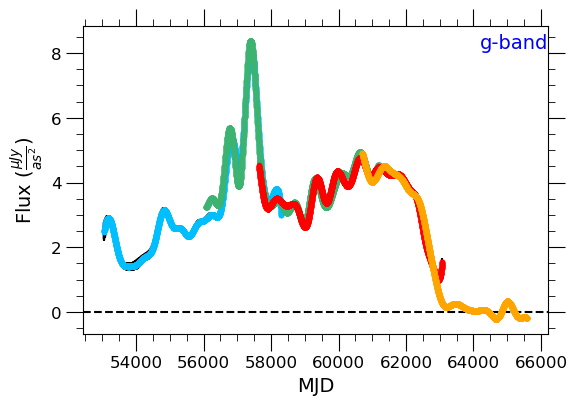

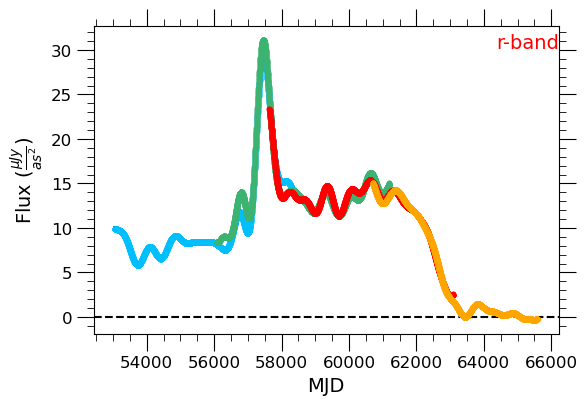

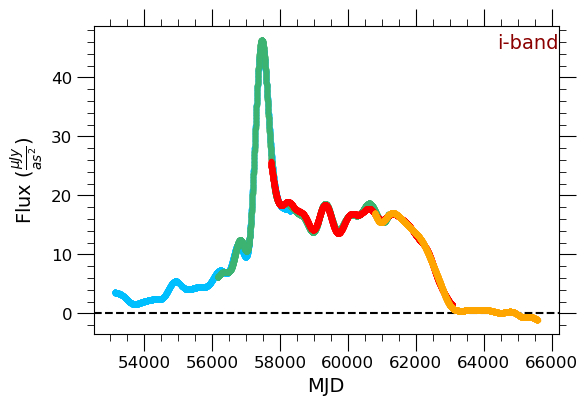

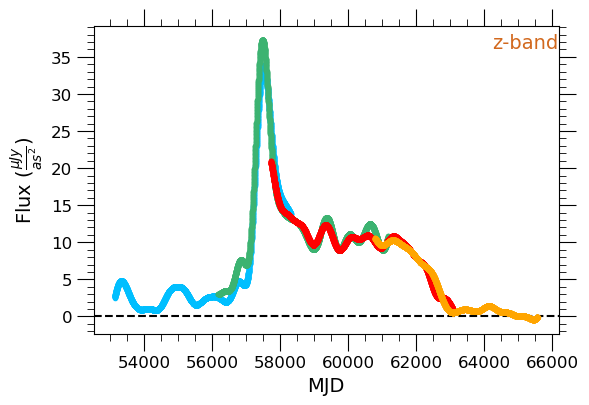

In [27]:
### See Connected Segments
fig, ax = plt.subplots(dpi = 100, figsize = [6,4])
ax.minorticks_on()
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
ax.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
ax.set_xlabel('MJD', fontsize = 14)
ax.set_ylabel('Flux ($\\frac{{\\mu}Jy}{{as}^2}$)', fontsize = 14)
ax.ticklabel_format(axis='both', style='plain')
ax.errorbar(m_t1g, m_f1g, yerr=m_ferr1g, fmt='--.', ecolor='black', color='deepskyblue', label='Loc 1')
ax.errorbar(m_t2g, m_f2g, yerr=m_ferr2g, fmt='--.', ecolor='black', color='mediumseagreen', label='Loc 2')
ax.errorbar(m_t3g, m_f3g, yerr=m_ferr3g, fmt='--.', ecolor='black', color='red', label='Loc 3')
ax.errorbar(m_t4g, m_f4g, yerr=m_ferr4g, fmt='--.', ecolor='black', color='orange', label='Loc 4')
ax.axhline(y=0, ls='--', color='k')
# fig.savefig('combined_segments.png', bbox_inches = 'tight', dpi=100)
plt.title('g-band', loc='right', y=0.9, color='blue', fontsize=14.)
plt.show()


fig, ax = plt.subplots(dpi = 100, figsize = [6,4])
ax.minorticks_on()
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
ax.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
ax.set_xlabel('MJD', fontsize = 14)
ax.set_ylabel('Flux ($\\frac{{\\mu}Jy}{{as}^2}$)', fontsize = 14)
ax.ticklabel_format(axis='both', style='plain')
ax.errorbar(m_t1r, m_f1r, yerr=m_ferr1r, fmt='--.', ecolor='black', color='deepskyblue', label='Loc 1')
ax.errorbar(m_t2r, m_f2r, yerr=m_ferr2r, fmt='--.', ecolor='black', color='mediumseagreen', label='Loc 2')
ax.errorbar(m_t3r, m_f3r, yerr=m_ferr3r, fmt='--.', ecolor='black', color='red', label='Loc 3')
ax.errorbar(m_t4r, m_f4r, yerr=m_ferr4r, fmt='--.', ecolor='black', color='orange', label='Loc 4')
ax.axhline(y=0, ls='--', color='k')
# fig.savefig('combined_segments.png', bbox_inches = 'tight', dpi=100)
plt.title('r-band', loc='right', y=0.9, color='red', fontsize=14.)
plt.show()


fig, ax = plt.subplots(dpi = 100, figsize = [6,4])
ax.minorticks_on()
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
ax.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
ax.set_xlabel('MJD', fontsize = 14)
ax.set_ylabel('Flux ($\\frac{{\\mu}Jy}{{as}^2}$)', fontsize = 14)
ax.ticklabel_format(axis='both', style='plain')
ax.errorbar(m_t1i, m_f1i, yerr=m_ferr1i, fmt='--.', ecolor='black', color='deepskyblue', label='Loc 1')
ax.errorbar(m_t2i, m_f2i, yerr=m_ferr2i, fmt='--.', ecolor='black', color='mediumseagreen', label='Loc 2')
ax.errorbar(m_t3i, m_f3i, yerr=m_ferr3i, fmt='--.', ecolor='black', color='red', label='Loc 3')
ax.errorbar(m_t4i, m_f4i, yerr=m_ferr4i, fmt='--.', ecolor='black', color='orange', label='Loc 4')
ax.axhline(y=0, ls='--', color='k')
# fig.savefig('combined_segments.png', bbox_inches = 'tight', dpi=100)
plt.title('i-band', loc='right', y=0.9, color='darkred', fontsize=14.)
plt.show()


fig, ax = plt.subplots(dpi = 100, figsize = [6,4])
ax.minorticks_on()
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
ax.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
ax.set_xlabel('MJD', fontsize = 14)
ax.set_ylabel('Flux ($\\frac{{\\mu}Jy}{{as}^2}$)', fontsize = 14)
ax.ticklabel_format(axis='both', style='plain')
ax.errorbar(m_t1z, m_f1z, yerr=m_ferr1z, fmt='--.', ecolor='black', color='deepskyblue', label='Loc 1')
ax.errorbar(m_t2z, m_f2z, yerr=m_ferr2z, fmt='--.', ecolor='black', color='mediumseagreen', label='Loc 2')
ax.errorbar(m_t3z, m_f3z, yerr=m_ferr3z, fmt='--.', ecolor='black', color='red', label='Loc 3')
ax.errorbar(m_t4z, m_f4z, yerr=m_ferr4z, fmt='--.', ecolor='black', color='orange', label='Loc 4')
ax.axhline(y=0, ls='--', color='k')
# fig.savefig('combined_segments.png', bbox_inches = 'tight', dpi=100)
plt.title('z-band', loc='right', y=0.9, color='chocolate', fontsize=14.)
plt.show()

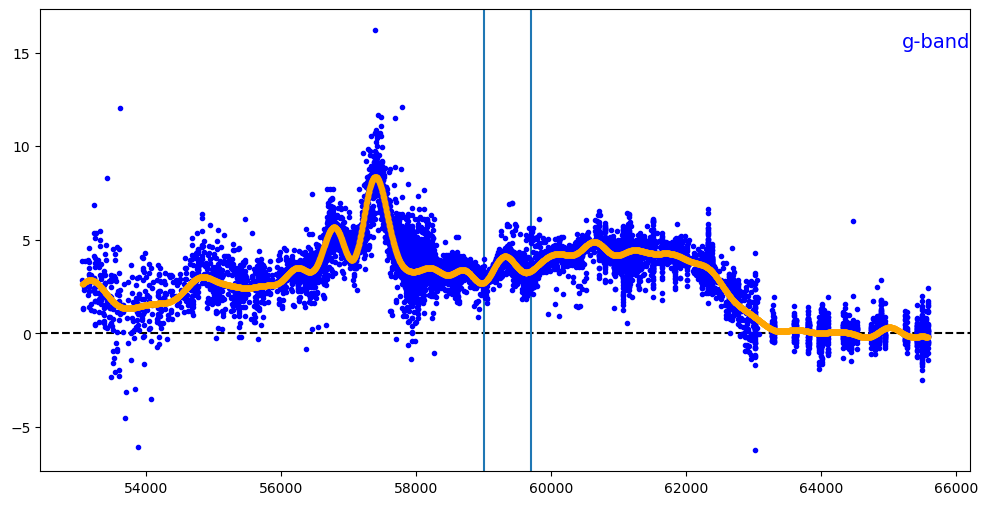

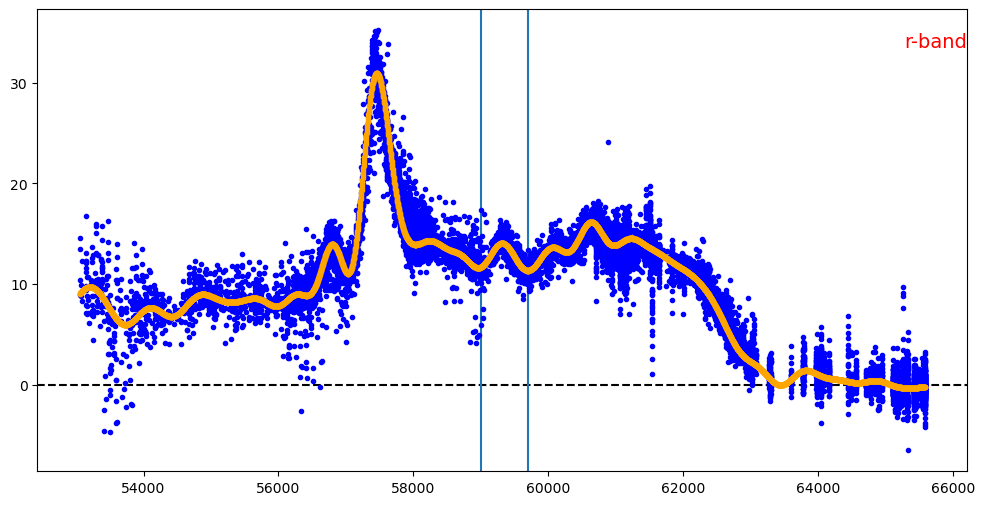

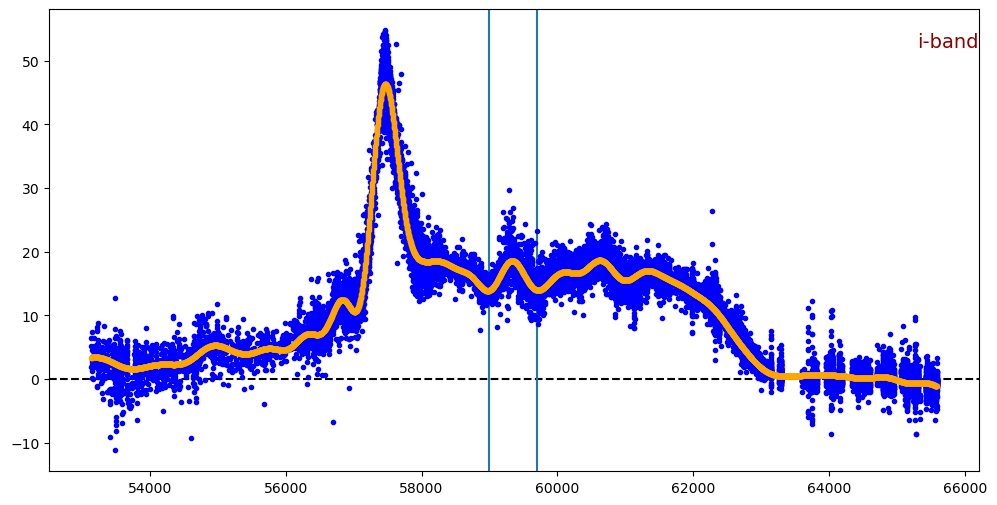

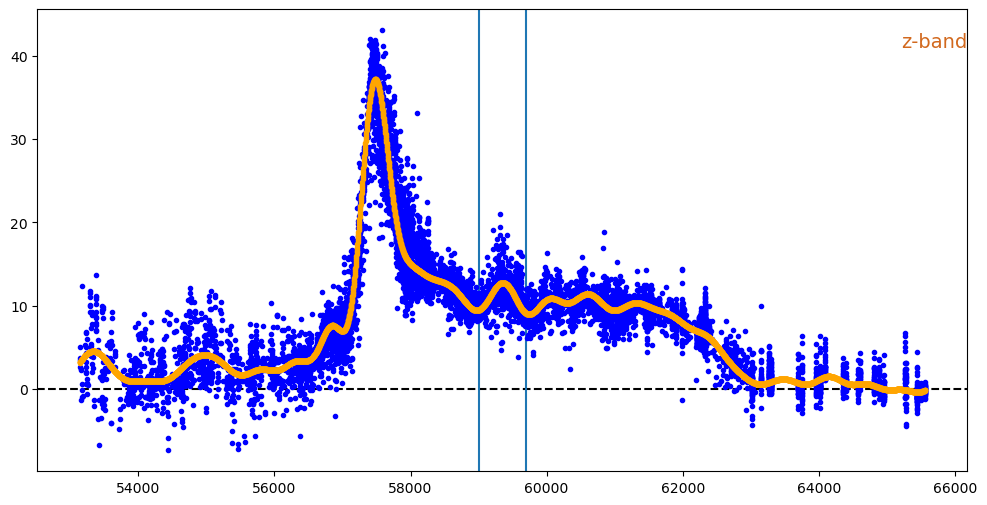

In [28]:
## Plot Model
plt.subplots(dpi = 100, figsize = [12,6])
plt.errorbar(comb_mg.t['mjd'], comb_mg.t['muJyas2'], fmt='.', ecolor='black', color='blue')
plt.errorbar(m_tg, m_mug, fmt='--.', ecolor='black', color='orange')
plt.axhline(y=0, linestyle='--', color='black')
plt.axvline(59000)
plt.axvline(59700)
plt.title('g-band', loc='right', y=0.9, color='blue', fontsize=14.)
plt.show()

plt.subplots(dpi = 100, figsize = [12,6])
plt.errorbar(comb_mr.t['mjd'], comb_mr.t['muJyas2'], fmt='.', ecolor='black', color='blue')
plt.errorbar(m_tr, m_mur, fmt='--.', ecolor='black', color='orange')
plt.axhline(y=0, linestyle='--', color='black')
plt.axvline(59000)
plt.axvline(59700)
plt.title('r-band', loc='right', y=0.9, color='red', fontsize=14.)
plt.show()

plt.subplots(dpi = 100, figsize = [12,6])
plt.errorbar(comb_mi.t['mjd'], comb_mi.t['muJyas2'], fmt='.', ecolor='black', color='blue')
plt.errorbar(m_ti, m_mui, fmt='--.', ecolor='black', color='orange')
plt.axhline(y=0, linestyle='--', color='black')
plt.axvline(59000)
plt.axvline(59700)
plt.title('i-band', loc='right', y=0.9, color='darkred', fontsize=14.)
plt.show()

plt.subplots(dpi = 100, figsize = [12,6])
plt.errorbar(comb_mz.t['mjd'], comb_mz.t['muJyas2'], fmt='.', ecolor='black', color='blue')
plt.errorbar(m_tz, m_muz, fmt='--.', ecolor='black', color='orange')
plt.axhline(y=0, linestyle='--', color='black')
plt.axvline(59000)
plt.axvline(59700)
plt.title('z-band', loc='right', y=0.9, color='chocolate', fontsize=14.)
plt.show()